# **STEP 1: IMPORT LIBRARIES**

Objective is to analyze stock market data using descriptive python tools and machine learning.

In [ ]:
#import libraries
import numpy as np #mathematical calc
import pandas as pd #importing files
import matplotlib.pyplot as plt #visualisation
import seaborn as sns #advanced visualisation
from openpyxl import load_workbook
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input

# **STEP 2: LOAD DATASET**

Imports file looks for start row.

This workbook analyzes only one stock at a time. Analyzed file can be changed on the second line of code by changing company name.

All company files need to be uploaded at the beginning of a session.

In [ ]:
#import (.xlsx) file
file = 'Price History_20260209_UPM-Kymmene_Oyj.xlsx'
name = file.replace('Price History_20260209_', '').replace('.xlsx', '').replace('_', ' ')

#Read workbook look for beginning row
wb = load_workbook(file, read_only=True)
ws = wb.active

skip_rows = 0
for row in ws.iter_rows(values_only=True):
    if row[0] == 'Exchange Date' or (row[0] and 'Exchange Date' in str(row[0])):
        break
    skip_rows += 1

wb.close()

#Read df from correct row
df = pd.read_excel(file, skiprows=skip_rows)
df = df.iloc[:, :10] # Select only the first 10 columns
df.columns = ['Date', 'Close/Last', 'Change', 'Change %', 'Open', 'High', 'Low', 'Volume', 'Turnover - EUR', 'Flow ']

df

,Date,Close/Last,Change,Change %,Open,High,Low,Volume,Turnover - EUR,Flow
0,2026-02-13,25.55,0.35,0.013889,25.34,25.30,25.61,180802,4.611203e+06,4.485402e+09
1,2026-02-06,25.20,1.83,0.078306,23.30,23.16,25.52,7320949,1.805621e+08,4.480791e+09
2,2026-01-30,23.37,-0.76,-0.031496,24.20,23.17,24.55,5492253,1.313954e+08,4.300229e+09
3,2026-01-23,24.13,-0.53,-0.021492,24.40,23.05,24.45,6481775,1.543742e+08,4.431624e+09
4,2026-01-16,24.66,0.01,0.000406,24.72,24.25,25.08,5712193,1.406667e+08,4.585998e+09
...,...,...,...,...,...,...,...,...,...,...
518,2016-03-11,15.55,-0.57,-0.035360,16.12,15.19,16.18,7181667,1.111550e+08,-2.582000e+06
519,2016-03-04,16.12,0.75,0.048796,15.26,15.21,16.25,7375058,1.169560e+08,1.085730e+08
520,2016-02-26,15.37,-0.26,-0.016635,15.80,14.98,16.11,7341717,1.135620e+08,-8.383000e+06
521,2016-02-19,15.63,1.49,0.105375,14.51,14.51,15.80,6927542,1.051790e+08,1.051790e+08


# **STEP 3: BASIC INFORMATION AND DIMENSIONS**

In [ ]:
#to find dimensions
df.shape #basic information
df.head()
df.info() #information


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            523 non-null    datetime64[ns]
 1   Close/Last      523 non-null    float64       
 2   Change          522 non-null    float64       
 3   Change %        522 non-null    float64       
 4   Open            523 non-null    float64       
 5   High            523 non-null    float64       
 6   Low             523 non-null    float64       
 7   Volume          523 non-null    int64         
 8   Turnover - EUR  523 non-null    float64       
 9   Flow            523 non-null    float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 41.0 KB


# **STEP 4: DATA CLEANING**

Only row containing null values is the oldest row and that can be deleted without issues.

In [ ]:
#to find missing values and nulls
df.isnull().sum()
df.dropna(inplace=True)


In [ ]:
df["Close/Last"].describe()
#show duplicates
#df.duplicated().sum()

,Close/Last
count,522.000000
mean,27.579330
std,4.765506
min,14.450000
25%,24.017500
50%,27.970000
75%,31.495000
max,36.950000


# **STEP 5: EXPLORATORY DATA-ANALYTICS**

Kone Oyj: Examining the historical price data reveals a non-linear upward trajectory punctuated by distinct phases of varying volatility. From 2016 through much of 2019, price exhibited a persistent, gradual appreciation characteristic of a mature bull market with low volatility and steady, fundamentals-driven growth. Entering late 2019, however, dynamics shifted to a rapid, exponential ascent, suggesting speculative fervor, before this trajectory was abruptly interrupted in early 2020 by a sharp but brief collapse attributable to a liquidity crisis. The covid-crisis period saw price remain unusually high through early 2022, a phase of multiple expansion likely driven by unprecedented stimulus that led to a decoupling from traditional valuation metrics until this unsustainable level culminated in a significant collapse in 2022, representing a forceful mean reversion. The aftermath brought a price recovery in 2023, a classic post-correction rebound, which was then followed by a retest of the 2022 lows that tested support levels. Finally, from 2024 onward, price has resumed a phase of steady, consistent increase, reflecting renewed accumulation and growing investor confidence leading up to the current moment.

UPM-Kymmene Oyj:
The stock trended upward from 2016 to 2022. After a period of steady consolidation, a price decrease in 2025 brought it back to test a key support level established during the 2019-2021 period.

Stock analysis is avalalbe for all stocks in Excel dashboard. In this report I have only written down analysis for Kone Oyj and UPM-Kymmene.

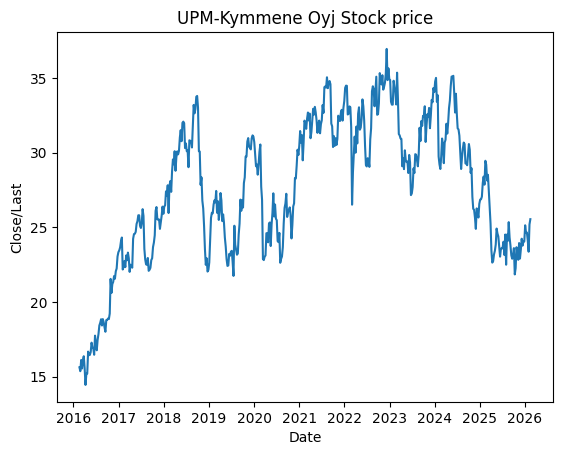

In [ ]:
#plot date and close/last
#show date as year
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
sns.lineplot(data=df, y='Close/Last', x='Date')
plt.title(name + ' Stock price')
plt.show()


Examining the relationship between turnover and stock price reveals important insights about trading activity. Turnover, representing the total value of shares traded, naturally correlates with price if the number of shares traded remains consistent, meaning higher prices mechanically produce higher turnover even with unchanged volume. Diverging patterns, however, signal shifts in the actual quantity of shares changing hands. When price increases but turnover remains flat, it suggests decreasing trading volume and thinning participation. When turnover rises faster than price, or increases during declines, it reveals growing activity, often reflecting heightened investor interest or panic selling. These divergences thus indicate whether price movements are accompanied by genuine shifts in market engagement or merely represent mechanical valuation changes.

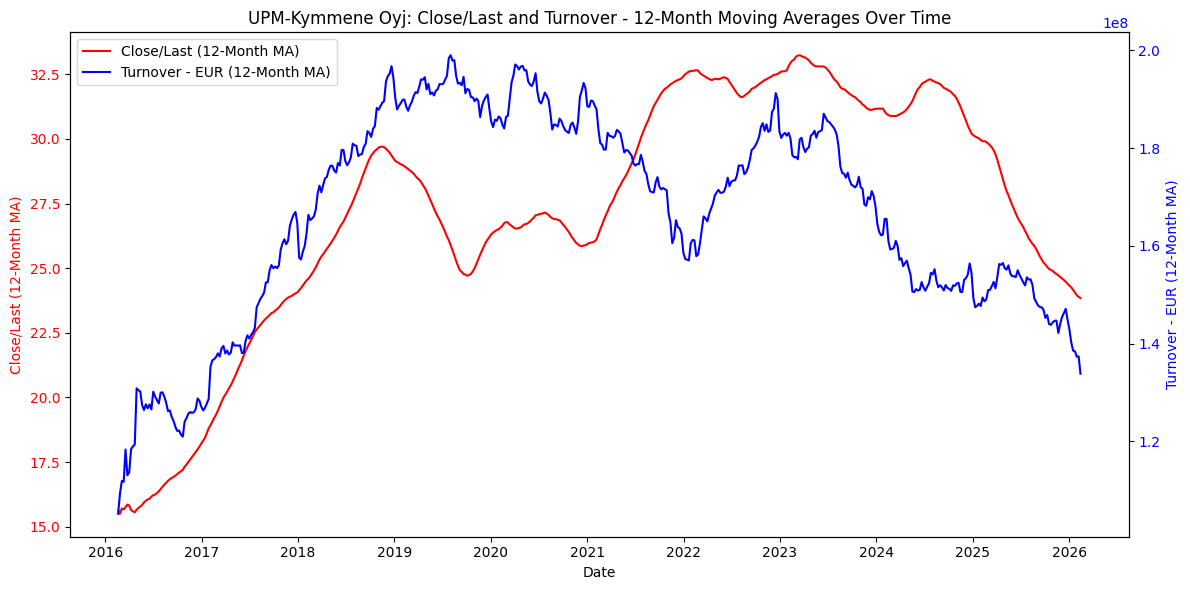

In [ ]:
# Turnover vs time and close/last vs time on one chart

# Sort the DataFrame by Date to ensure correct rolling average calculation
df = df.sort_values(by='Date')

# Calculate the 12-month (approximately 48 weeks) rolling average for Close/Last and Turnover
# Given the data is weekly, 12 months is roughly 48 data points.
df['Close/Last_12M_MA'] = df['Close/Last'].rolling(window=48, min_periods=1).mean()
df['Turnover_EUR_12M_MA'] = df['Turnover - EUR'].rolling(window=48, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Close/Last 12-month moving average
ax1.plot(df['Date'], df['Close/Last_12M_MA'], 'r-', label='Close/Last (12-Month MA)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Close/Last (12-Month MA)', color='r')
ax1.tick_params(axis='y', labelcolor='r')

# Create a second y-axis for Turnover
ax2 = ax1.twinx()
ax2.plot(df['Date'], df['Turnover_EUR_12M_MA'], 'b-', label='Turnover - EUR (12-Month MA)')
ax2.set_ylabel('Turnover - EUR (12-Month MA)', color='b')
ax2.tick_params(axis='y', labelcolor='b')

# Add title and legend
plt.title(name +': Close/Last and Turnover - 12-Month Moving Averages Over Time')
fig.tight_layout()
# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.show()

12 MONTH MOVING AVERAGE

This chart show moving average over 12 month of price vs closing price. Stock can be seen as over valued when its price is significantly above moving average and undervalued when its below. Overall moving average shows trend of the stock price over long period of time.

Kone Oyj: Stock price was steady over period of 2016 to 2019. Overvalued from 2019 to 2021, undervalued 2021 to 2024 and lately has been growing setadily above the 12 month moving average with occasional dips to test the moving average.

UPM-Kymmene: The price is currently moving toward its 12-month MA from below. Historically, this average has acted more as resistance than a consistent support level.

Text(0, 0.5, 'Close/Last')

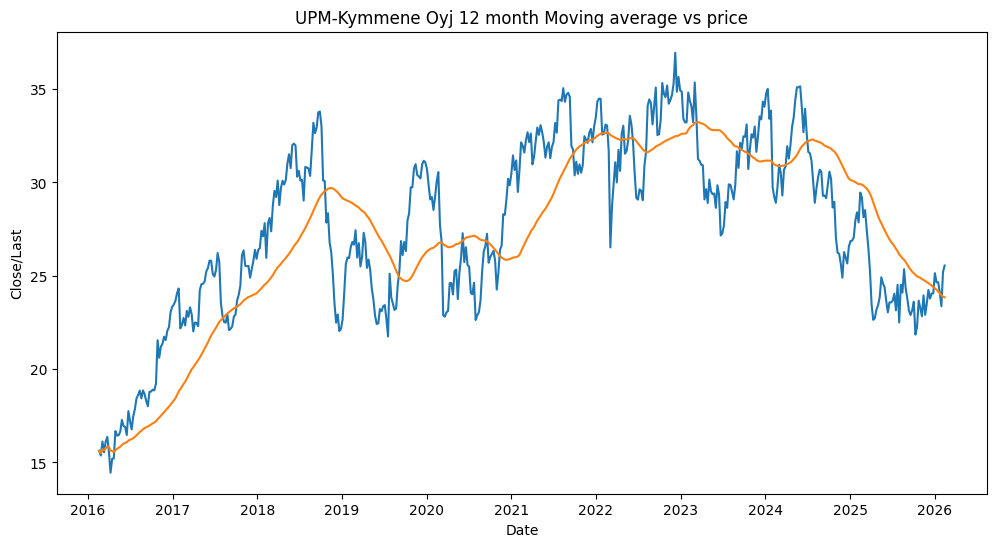

In [ ]:
#Close/last and 12-month movig average plotted vs date
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close/Last'], label='Close/Last')
plt.plot(df['Date'], df['Close/Last_12M_MA'], label='Close/Last (12-month MA)')
plt.title(name+' 12 month Moving average vs price')
plt.xlabel('Date')
plt.ylabel('Close/Last')


RELATIVE STRENGHT INDEX

Relative strength index is a more refined version of simple moving average. RSI measures the magnitude and velocity of recent price changes to evaluate overbought or oversold conditions. Calculating the ratio of upward movements to downward movements over a specified period, typically 14 days. Unlike a simple moving average which merely smooths price data to show trend direction, RSI oscillates between zero and one hundred, providing boundaries that generate potential reversal signals when extreme levels are reached. Values above seventy suggest an asset may be overbought and due for a pullback, while values below thirty indicate potential oversold conditions. This momentum oscillator thus captures not just where price has been, but the internal strength or weakness behind the movement.

Kone Oyj:
For Kone few periods of overselling and overbuying can be identified using RSI analysis. Current moment presents opportinity to wait for oversold conditions to appear before making a purchase of sock.

UPM-Kymmene:
The RSI is in a neutral position, recovering from the mid-2025 sell-off. This leaves ample room for upward movement before entering overbought territory.

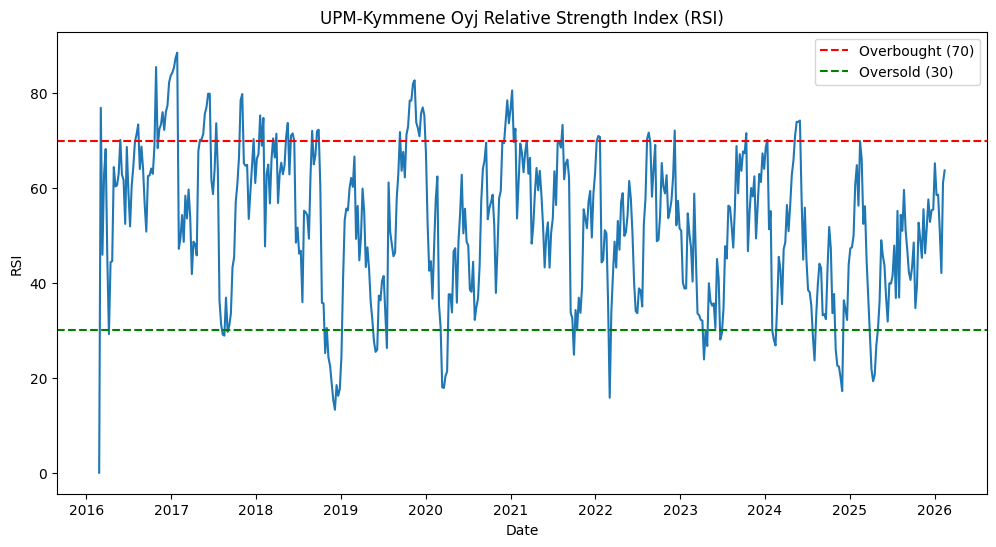

In [ ]:
df['Price Change'] = df['Close/Last'].diff()
df['Gain'] = df['Price Change'].apply(lambda x: x if x > 0 else 0)
df['Loss'] = df['Price Change'].apply(lambda x: abs(x) if x < 0 else 0)
window_length = 14
df['Avg Gain'] = df['Gain'].ewm(span=window_length, adjust=False).mean()
df['Avg Loss'] = df['Loss'].ewm(span=window_length, adjust=False).mean()
df['RS'] = df['Avg Gain'] / df['Avg Loss']
df['RSI'] = 100 - (100 / (1 + df['RS']))
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='RSI')
plt.title(name +' Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.legend()
plt.show()

# **STEP 6: FEATURE SELECTION**

This chart is exploring relationship between differet factors in price history file. Using this analysis we can't see any menaingful relationships to be used for price prediction.

<Axes: >

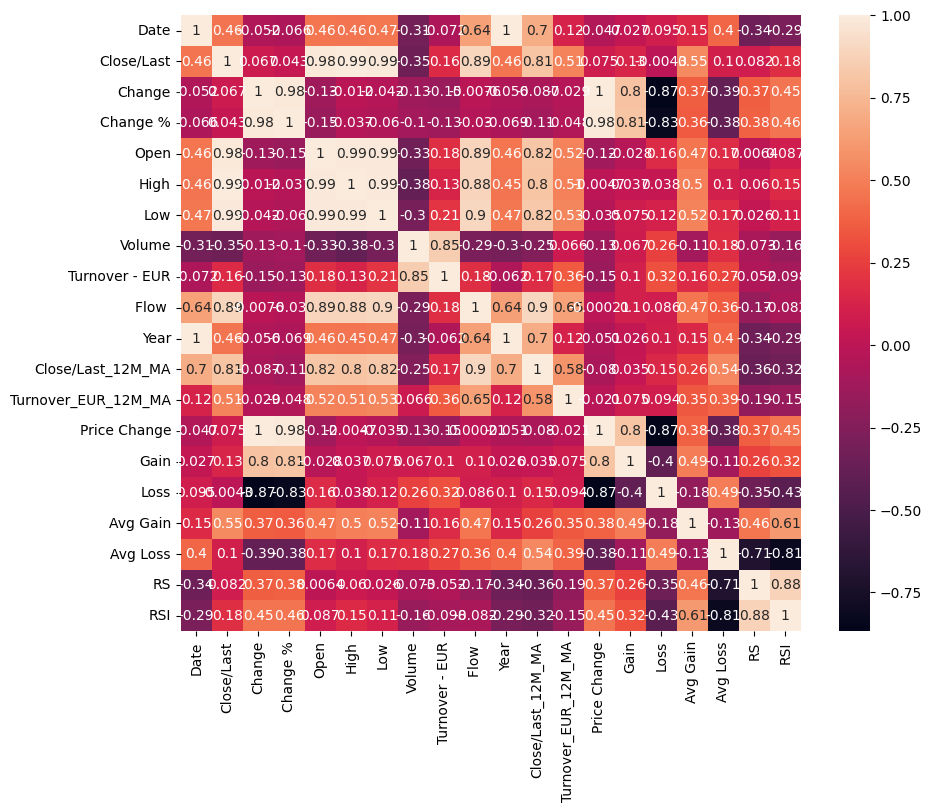

In [ ]:
#plot corelation plot
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True)

# **STEP 7: MODEL TRAINING AND COMPARISON**

LOGISTIC REGRESSION

Logistic regression is a widely used statistical method for analyzing the relationship between patient characteristics, or predictor variables, and clinical outcomes. It estimates the probability that a particular event will occur based on information thought to influence such events, making it particularly suitable for binary outcomes such as lived versus died. A key strength of logistic regression is its ability to adjust for confounding factors—variables associated with both other predictors and the outcome—thereby isolating the unique influence of each predictor of interest. The method quantifies these relationships through odds, which represent the probability of an event occurring divided by the probability of it not occurring, allowing researchers to identify which factors have the strongest association with an outcome. (Tolles and Meurer, 2016).

In [ ]:
# Create 'status' column: 1 if Close/Last increased, 0 otherwise
df['status'] = (df['Price Change'] > 0).astype(int)


# Ensure 'status' is an integer type
df['status'] = df['status'].astype(int)

#split the dataset with status column
x = df.drop('status', axis=1) #axis=1 means the column, axis=0 means rows!
y = df['status']

# Exclude non-numeric columns from x before splitting and training
x = x.select_dtypes(include=[np.number])

# Replace infinite values with NaN and then drop rows with NaN values
x.replace([np.inf, -np.inf], np.nan, inplace=True)
x.dropna(inplace=True)

# Align y with the cleaned x (after dropping rows)
y = y[x.index]

#split dataset into trained and test data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

from functools import lru_cache
from sklearn import linear_model
#logistic regression
#create and train logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear', random_state=42) # Added solver for convergence
model.fit(x_train, y_train)

#predict
y_pred_lr = model.predict(x_test)

#evaluate
from sklearn.metrics import accuracy_score
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print('Logistic Regression Accuracy:', lr_accuracy)


Logistic Regression Accuracy: 0.5619047619047619


In [ ]:
last_date = df['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=8, freq='W')
print("Last date in historical data:", last_date)

average_increase = df[df['status'] == 1]['Price Change'].mean()
print(f"Average increase when status=1: {average_increase:.2f}%")

future_df = pd.DataFrame({'Date': future_dates})

# Identify numerical columns from x (which was used for training)
# Exclude 'Date' and 'status' which are handled separately or not present in x
numerical_cols_for_model = x.columns

# Get the last known values from the original df for these columns
last_known_values = df[numerical_cols_for_model].iloc[-1]

# Populate future_df with these last known values
for col in numerical_cols_for_model:
    future_df[col] = last_known_values[col]

future_df_for_prediction = future_df[numerical_cols_for_model]

# Predict the 'status' for future dates
future_predictions = model.predict(future_df_for_prediction)

# Add predictions to the future_df
future_df['Predicted Status'] = future_predictions

# Map numerical status to descriptive labels
future_df['Predicted Status'] = future_df['Predicted Status'].map({1: 'Increase', 0: 'Decrease'})

#add mean increase to model
future_df['Mean Increase'] = average_increase

# Print the future predictions

print("Future predictions for stock market status:")
print(future_df[['Date', 'Predicted Status']].head(3))

Last date in historical data: 2026-02-13 00:00:00
Average increase when status=1: 0.70%
Future predictions for stock market status:
        Date Predicted Status
0 2026-02-15         Increase
1 2026-02-22         Increase
2 2026-03-01         Increase


RANDOM FORREST AND DECICION TREE

Random forrest is similar to logistic regression that it predicts next periods in series on wheather the price is increasing or decreasing. While logistic regression is a linear model, Random Forest is an ensemble method combining multiple decision trees.

This code trains random forrest and decicion tree models and then creates predictions based on this training. The predictions are compared to actual historical data to estimate their accuracy. Finally, all three models are compared in visualization based on their accuracy scores.

Decision Tree Accuracy: 1.0
[1 1 0 1 0 1 1 1 0 0 1 1 0 1 0 1 0 1 0 0 0 1 1 1 1 0 0 0 1 1 1 0 0 1 0 0 0
 1 1 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 1 0 0 0 1 1 0 1
 0 1 1 0 1 1 1 0 0 0 0 0 1 1 1 1 1 0 0 1 1 1 0 1 0 1 0 0 1 0 0]
Random Forest Accuracy: 1.0


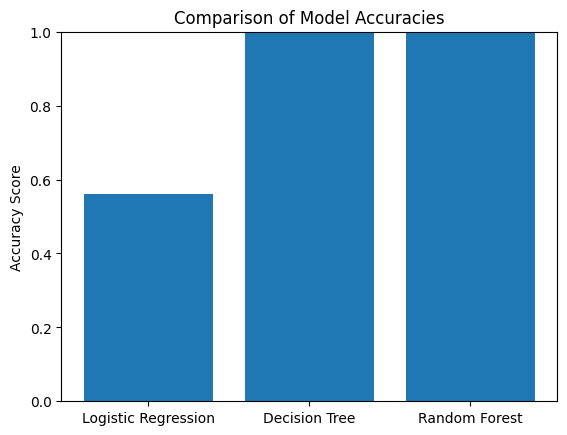

,Actual,Predicted
0,1,1
1,1,1
2,0,1
3,1,1
4,0,1
5,1,1
6,1,1
7,1,1
8,0,1
9,0,1


In [ ]:
dt_model = DecisionTreeClassifier(random_state=42) # Corrected: instantiated the class
dt_model.fit(x_train, y_train)

#predict
y_pred_dt = dt_model.predict(x_test)

#evaluate
#from sklearn.metrics import accuracy_score
dt_accuracy = accuracy_score(y_test, y_pred_dt) # Corrected: using y_pred_dt
print('Decision Tree Accuracy:', dt_accuracy)
#

#create and train Random forest model
#from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42) # Added random_state for reproducibility
rf_model.fit(x_train, y_train)

#predict
y_pred_rf = rf_model.predict(x_test) # Corrected: making predictions

#show predictions
print(y_pred_rf)


#evaluate
#from sklearn.metrics import accuracy_score
rf_accuracy = accuracy_score(y_test, y_pred_rf) # Corrected: using y_pred_rf
print('Random Forest Accuracy:', rf_accuracy)


# comparision of these models accuracy score results in a bar graph
models_accuracy = {'Logistic Regression': lr_accuracy, 'Decision Tree': dt_accuracy, 'Random Forest': rf_accuracy}
plt.bar(models_accuracy.keys(), models_accuracy.values())
plt.title('Comparison of Model Accuracies')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1) # Accuracy scores are between 0 and 1
plt.show()

#compare actual y_test values with prediction model results and only first 10 rows
comparison=pd.DataFrame({'Actual':y_test.values[:10], 'Predicted':y_pred_lr[:10]}) # Fixed: Slicing y_test to match y_pred_lr
comparison


In [ ]:
future_predictions_rf = rf_model.predict(future_df_for_prediction)
future_df['Predicted Status (RF)'] = future_predictions_rf
future_df['Predicted Status (RF)'] = future_df['Predicted Status (RF)'].map({1: 'Increase', 0: 'Decrease'})

future_predictions_dt = dt_model.predict(future_df_for_prediction)
future_df['Predicted Status (DT)'] = future_predictions_dt
future_df['Predicted Status (DT)'] = future_df['Predicted Status (DT)'].map({1: 'Increase', 0: 'Decrease'})

print("Future predictions for stock market status (first 3 dates) using Random Forest and Decision Tree:")
print(future_df[['Date', 'Predicted Status (RF)', 'Predicted Status (DT)']].head(3))

#from sklearn.model_selection import train_test_split

# 1. Define y_reg as the 'Price Change' column
y_reg = df['Price Change']

# 2. Create x_reg by dropping specified columns and selecting only numeric ones
x_reg = df.drop(columns=['Price Change', 'status', 'Date', 'Year'], errors='ignore')
x_reg = x_reg.select_dtypes(include=[np.number])

# 3. Handle any potential infinite or NaN values in x_reg
x_reg.replace([np.inf, -np.inf], np.nan, inplace=True)
x_reg.dropna(inplace=True)

# 4. Align y_reg with the cleaned x_reg
y_reg = y_reg[x_reg.index]

# 5. Split x_reg and y_reg into training and testing sets
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(
    x_reg, y_reg, test_size=0.2, random_state=42
)

print("Data for regression model prepared.")
print(f"x_reg shape: {x_reg.shape}")
print(f"y_reg shape: {y_reg.shape}")
print(f"x_train_reg shape: {x_train_reg.shape}")
print(f"x_test_reg shape: {x_test_reg.shape}")

from sklearn.ensemble import RandomForestRegressor

# Instantiate a RandomForestRegressor model
rf_regressor = RandomForestRegressor(random_state=42)

# Fit the model to the training data
rf_regressor.fit(x_train_reg, y_train_reg)

print("Random Forest Regressor model trained successfully.")

future_df_for_prediction_reg = future_df[x_reg.columns].head(3)

# Predict the price change for these future dates
future_price_change_predictions = rf_regressor.predict(future_df_for_prediction_reg)

# Add these predictions to the future_df DataFrame
# Ensure that the predictions are assigned to the correct rows (first 3)
future_df.loc[future_df_for_prediction_reg.index, 'Predicted Price Change (RF)'] = future_price_change_predictions

print("Predicted Price Change for the first 3 future dates using Random Forest Regressor:")
print(future_df[['Date', 'Predicted Price Change (RF)']].head(3))

last_known_close_last = df['Close/Last'].iloc[-1]

future_df.loc[future_df_for_prediction_reg.index, 'Predicted Percentage Change (RF)'] = \
    (future_df.loc[future_df_for_prediction_reg.index, 'Predicted Price Change (RF)'] / last_known_close_last) * 100

print("Predicted Percentage Change for the first 3 future dates:")
print(future_df[['Date', 'Predicted Price Change (RF)', 'Predicted Percentage Change (RF)']].head(3))

Future predictions for stock market status (first 3 dates) using Random Forest and Decision Tree:
        Date Predicted Status (RF) Predicted Status (DT)
0 2026-02-15              Increase              Increase
1 2026-02-22              Increase              Increase
2 2026-03-01              Increase              Increase
Data for regression model prepared.
x_reg shape: (521, 17)
y_reg shape: (521,)
x_train_reg shape: (416, 17)
x_test_reg shape: (105, 17)
Random Forest Regressor model trained successfully.
Predicted Price Change for the first 3 future dates using Random Forest Regressor:
        Date  Predicted Price Change (RF)
0 2026-02-15                       0.3517
1 2026-02-22                       0.3517
2 2026-03-01                       0.3517
Predicted Percentage Change for the first 3 future dates:
        Date  Predicted Price Change (RF)  Predicted Percentage Change (RF)
0 2026-02-15                       0.3517                          1.376517
1 2026-02-22             

LSTM MODEL

Long Short-Term Memory (LSTM) is a specialized recurrent neural network architecture designed to learn long-term dependencies. Building on the version with forget gates introduced by Gers et al. Its fundamental building block is the memory block, which contains one or more memory cells and three adaptive, multiplicative gates. At the core of each memory cell is a self-connected linear unit called the Constant Error Carousel (CEC), which allows error signals to flow backwards indefinitely, effectively overcoming the vanishing gradient problem. The input, forget, and output gates are trained to regulate information flow by learning what to store, how long to retain it, and when to read it out. By combining multiple memory cells into blocks that can share the same gates, the architecture reduces the number of adaptive parameters while providing short-term memory storage for extended time periods. (Gers, Schraudolph and Schmidhuber, 2002).


In [ ]:
# 1. Select the 'Close/Last' column and convert it into a NumPy array.
data = df['Close/Last'].values.reshape(-1, 1)

# 2. Initialize a MinMaxScaler to scale the data between 0 and 1.
scaler = MinMaxScaler(feature_range=(0, 1))

# 3. Fit the scaler to the 'Close/Last' data and transform it.
scaled_data = scaler.fit_transform(data)

print("Shape of original data:", data.shape)
print("Shape of scaled data:", scaled_data.shape)
print("First 5 scaled data points:\n", scaled_data[:5])

# 4. Define a look_back period
look_back = 60 # Using 60 as an example, typically chosen based on data frequency and patterns

# 5. Create a function, create_sequences, that takes the scaled_data and look_back as input.
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

# 6. Apply the create_sequences function to your scaled_data to get X and y for the LSTM.
X, y = create_sequences(scaled_data, look_back)

# 7. Reshape the input sequences X into a 3D array of the format (samples, timesteps, features).
# Since we are using a single feature ('Close/Last'), the features dimension will be 1.
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"Shape of X (input sequences): {X.shape}")
print(f"Shape of y (target values): {y.shape}")
print(f"First sequence of X:\n{X[0].flatten()}")
print(f"First target value of y: {y[0]}")

Shape of original data: (522, 1)
Shape of scaled data: (522, 1)
First 5 scaled data points:
 [[0.05244444]
 [0.04088889]
 [0.07422222]
 [0.04888889]
 [0.07377778]]
Shape of X (input sequences): (462, 60, 1)
Shape of y (target values): (462,)
First sequence of X:
[0.05244444 0.04088889 0.07422222 0.04888889 0.07377778 0.08533333
 0.05022222 0.         0.03333333 0.03377778 0.09911111 0.08844444
 0.08933333 0.09777778 0.12577778 0.11111111 0.10888889 0.08977778
 0.14666667 0.12311111 0.10311111 0.13422222 0.15155556 0.17688889
 0.18488889 0.19555556 0.17688889 0.196      0.18666667 0.17111111
 0.15822222 0.19288889 0.19333333 0.19777778 0.196      0.21244444
 0.31555556 0.27377778 0.3        0.30666667 0.324      0.316
 0.33822222 0.34666667 0.38222222 0.39511111 0.40044444 0.40933333
 0.428      0.43866667 0.34355556 0.35155556 0.36844444 0.35066667
 0.38533333 0.37111111 0.39377778 0.37733333 0.33644444 0.35777778]
First target value of y: 0.356


In [ ]:
# 2. Initialize a Sequential model.
model = Sequential()

# Add an Input layer to explicitly define the input shape
model.add(Input(shape=(look_back, 1)))

# 3. Add an LSTM layer to the model. The input_shape is now implicitly handled by the preceding Input layer.
model.add(LSTM(units=50))

# 4. Add a Dense output layer with one unit
model.add(Dense(units=1))

# 5. Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# 6. Print the model summary
model.summary()

history = model.fit(
X,
y,
epochs=100,      # Number of training iterations
batch_size=32,   # Number of samples per gradient update
validation_split=0.2, # Fraction of the training data to be used as validation data
verbose=1        # Display training progress
)

print("LSTM model training complete.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.3567 - val_loss: 0.0135
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0321 - val_loss: 0.0173
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0155 - val_loss: 0.0090
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0122 - val_loss: 0.0175
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0122 - val_loss: 0.0119
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0112 - val_loss: 0.0115
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0107 - val_loss: 0.0122
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0103 - val_loss: 0.0099
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0102 - val_loss: 0.0107
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0100 - val_loss: 0.0105
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0096 - val_loss: 0.0090
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

In [ ]:
history = model.fit(
X,
y,
epochs=100,      # Number of training iterations
batch_size=32,   # Number of samples per gradient update
validation_split=0.2, # Fraction of the training data to be used as validation data
verbose=1        # Display training progress
)

print("LSTM model training complete.")

# 1. Extract the last look_back values from the scaled_data to serve as the initial input sequence.
last_sequence = scaled_data[-look_back:]

# Reshape this sequence into the 3D format (1, look_back, 1) as required by the LSTM model.
last_sequence = last_sequence.reshape(1, look_back, 1)

# 2. Initialize an empty list, for example, future_predictions_scaled, to store the scaled predictions.
future_predictions_scaled = []

print(f"Initial last_sequence shape: {last_sequence.shape}")
print(f"First few values of initial last_sequence:\n{last_sequence[0,:5].flatten()}")

# 3. Iterate len(future_df) times (to predict for 8 future dates):
for _ in range(len(future_df)):
    # a. Use the trained model to predict the next 'Close/Last' value from the current last_sequence.
    next_prediction_scaled = model.predict(last_sequence)

    # b. Append this scaled prediction to the future_predictions_scaled list.
    future_predictions_scaled.append(next_prediction_scaled[0, 0])

    # c. Update last_sequence by removing its first element and adding the new scaled prediction to its end.
    # This allows for multi-step forecasting.
    new_sequence_element = next_prediction_scaled.reshape(1, 1, 1)
    last_sequence = np.append(last_sequence[:, 1:, :], new_sequence_element, axis=1)

# 4. Convert the future_predictions_scaled list into a NumPy array.
future_predictions_scaled_array = np.array(future_predictions_scaled).reshape(-1, 1)

# 5. Inverse transform the future_predictions_scaled array using the scaler object
# to obtain the actual predicted 'Close/Last' prices.
future_predictions_actual = scaler.inverse_transform(future_predictions_scaled_array)

# 6. Add these future_predictions_actual to the existing future_df DataFrame,
# creating a new column named 'Predicted Close/Last (LSTM)'.
# Ensure the length matches. Assuming future_df has 8 rows as per the problem description.
future_df['Predicted Close/Last (LSTM)'] = future_predictions_actual

print("Predicted future 'Close/Last' prices using LSTM:")
print(future_df[['Date', 'Predicted Close/Last (LSTM)']])


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0029 - val_loss: 0.0022
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0030 - val_loss: 0.0026
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0030 - val_loss: 0.0032
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0030 - val_loss: 0.0020
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0029 - val_loss: 0.0018
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0029 - val_loss: 0.0018
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0027 - val_loss: 0.0021
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0027 - val_loss: 0.0031
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0029 - val_loss: 0.0019
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0028 - val_loss: 0.0018
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0028 - val_loss: 0.0021
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Shape of original data: (522, 1)
Shape of scaled data: (522, 1)
First 5 scaled data points:
 [[0.05244444]
 [0.04088889]
 [0.07422222]
 [0.04888889]
 [0.07377778]]
Shape of X (input sequences): (462, 60, 1)
Shape of y (target values): (462,)
First sequence of X:
[0.05244444 0.04088889 0.07422222 0.04888889 0.07377778 0.08533333
 0.05022222 0.         0.03333333 0.03377778 0.09911111 0.08844444
 0.08933333 0.09777778 0.12577778 0.11111111 0.10888889 0.08977778
 0.14666667 0.12311111 0.10311111 0.13422222 0.15155556 0.17688889
 0.18488889 0.19555556 0.17688889 0.196      0.18666667 0.17111111
 0.15822222 0.19288889 0.19333333 0.19777778 0.196      0.21244444
 0.31555556 0.27377778 0.3        0.30666667 0.324      0.316
 0.33822222 0.34666667 0.38222222 0.39511111 0.40044444 0.40933333
 0.428      0.43866667 0.34355556 0.35155556 0.36844444 0.35066667
 0.38533333 0.37111111 0.39377778 0.37733333 0.33644444 0.35777778]
First target value of y: 0.356


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.2119 - val_loss: 0.0189
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0240 - val_loss: 0.0061
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0133 - val_loss: 0.0065
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0091 - val_loss: 0.0110
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0084 - val_loss: 0.0071
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0083 - val_loss: 0.0083
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0081 - val_loss: 0.0079
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0080 - val_loss: 0.0078
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0078 - val_loss: 0.0070
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0078 - val_loss: 0.0077
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0079 - val_loss: 0.0066
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step

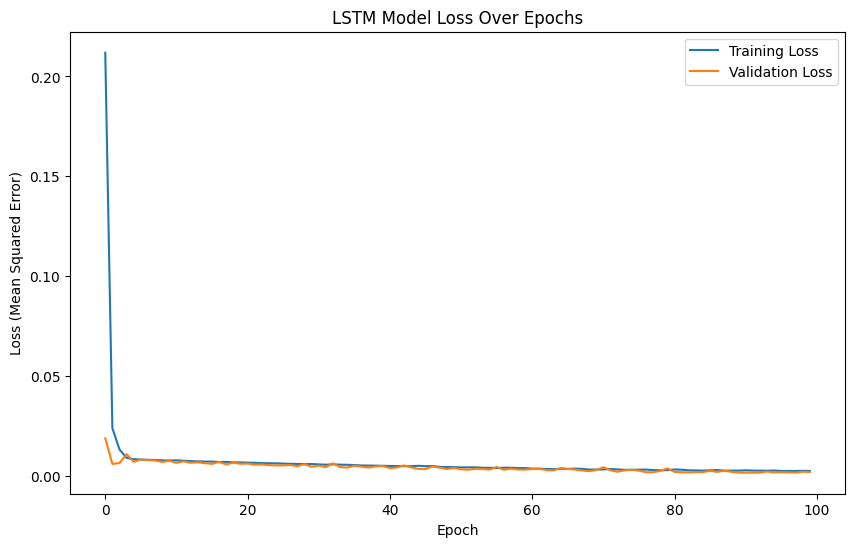

Initial last_sequence shape: (1, 60, 1)
First few values of initial last_sequence:
[0.53866667 0.55155556 0.55244444 0.56044444 0.60088889]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted future 'Close/Last' prices using LSTM:
        Date  Predicted Close/Last (LSTM)
0 2026-02-15                    25.399761
1 2026-02-22                    25.701256
2 2026-03-01                    25.975418
3 2026-03-08                    26.229414


In [ ]:
# 1. Select the 'Close/Last' column and convert it into a NumPy array.
data = df['Close/Last'].values.reshape(-1, 1)

# 2. Initialize a MinMaxScaler to scale the data between 0 and 1.
scaler = MinMaxScaler(feature_range=(0, 1))

# 3. Fit the scaler to the 'Close/Last' data and transform it.
scaled_data = scaler.fit_transform(data)

print("Shape of original data:", data.shape)
print("Shape of scaled data:", scaled_data.shape)
print("First 5 scaled data points:\n", scaled_data[:5])


# 4. Define a look_back period
look_back = 60 # Using 60 as an example, typically chosen based on data frequency and patterns

# 5. Create a function, create_sequences, that takes the scaled_data and look_back as input.
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

# 6. Apply the create_sequences function to your scaled_data to get X and y for the LSTM.
X, y = create_sequences(scaled_data, look_back)

# 7. Reshape the input sequences X into a 3D array of the format (samples, timesteps, features).
# Since we are using a single feature ('Close/Last'), the features dimension will be 1.
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"Shape of X (input sequences): {X.shape}")
print(f"Shape of y (target values): {y.shape}")
print(f"First sequence of X:\n{X[0].flatten()}")
print(f"First target value of y: {y[0]}")

from keras.models import Sequential
from keras.layers import LSTM, Dense

# 2. Initialize a Sequential model.
model = Sequential()

# 3. Add an LSTM layer to the model.
# The input_shape is (timesteps, features). Here, timesteps = look_back, features = 1.
model.add(LSTM(units=50, input_shape=(look_back, 1)))

# 4. Add a Dense output layer with one unit
model.add(Dense(units=1))

# 5. Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# 6. Print the model summary
model.summary()

history = model.fit(
X,
y,
epochs=100,      # Number of training iterations
batch_size=32,   # Number of samples per gradient update
validation_split=0.2, # Fraction of the training data to be used as validation data
verbose=1        # Display training progress
)

print("LSTM model training complete.")


plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.show()

# 1. Extract the last look_back values from the scaled_data to serve as the initial input sequence.
last_sequence = scaled_data[-look_back:]

# Reshape this sequence into the 3D format (1, look_back, 1) as required by the LSTM model.
last_sequence = last_sequence.reshape(1, look_back, 1)

# 2. Initialize an empty list, for example, future_predictions_scaled, to store the scaled predictions.
future_predictions_scaled = []

print(f"Initial last_sequence shape: {last_sequence.shape}")
print(f"First few values of initial last_sequence:\n{last_sequence[0,:5].flatten()}")

# 3. Iterate len(future_df) times (to predict for 8 future dates):
for _ in range(len(future_df)):
    # a. Use the trained model to predict the next 'Close/Last' value from the current last_sequence.
    next_prediction_scaled = model.predict(last_sequence)

    # b. Append this scaled prediction to the future_predictions_scaled list.
    future_predictions_scaled.append(next_prediction_scaled[0, 0])

    # c. Update last_sequence by removing its first element and adding the new scaled prediction to its end.
    # This allows for multi-step forecasting.
    new_sequence_element = next_prediction_scaled.reshape(1, 1, 1)
    last_sequence = np.append(last_sequence[:, 1:, :], new_sequence_element, axis=1)

# 4. Convert the future_predictions_scaled list into a NumPy array.
future_predictions_scaled_array = np.array(future_predictions_scaled).reshape(-1, 1)

# 5. Inverse transform the future_predictions_scaled array using the scaler object
# to obtain the actual predicted 'Close/Last' prices.
future_predictions_actual = scaler.inverse_transform(future_predictions_scaled_array)

# 6. Add these future_predictions_actual to the existing future_df DataFrame,
# creating a new column named 'Predicted Close/Last (LSTM)'.
future_df['Predicted Close/Last (LSTM)'] = future_predictions_actual

print("Predicted future 'Close/Last' prices using LSTM:")
print(future_df[['Date', 'Predicted Close/Last (LSTM)']].iloc[:4])

ANN

Artificial Neural Networks (ANNs) are computing systems inspired by the human brain, consisting of interconnected neurons organized in layers (input, hidden, and output) that process information by assigning importance to inputs through weight factors. Each neuron functions by multiplying inputs by weights, summing them with a bias, and passing the result through an activation function like the sigmoid, which maps values to a range between 0 and 1. These networks learn by comparing their predicted output against the actual result from training data, using a "loss function" to measure the error. The key to learning is the continuous adjustment of the weights between neurons, strengthening important connections to improve accuracy, similar to figuring out which classmate gives the best answers. The goal of training is to minimize the loss function, ideally to zero, meaning the network's prediction perfectly matches the expected outcome. (Lang, 2021).

Shape of X_ann (input sequences for ANN): (462, 60)
Shape of y_ann (target values for ANN): (462,)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 100)            │         6,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,201 (43.75 KB)

 Trainable params: 11,201 (43.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.2960 - val_loss: 0.1100
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0347 - val_loss: 0.0177
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0228 - val_loss: 0.0200
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0195 - val_loss: 0.0272
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0158 - val_loss: 0.0130
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0142 - val_loss: 0.0103
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0129 - val_loss: 0.0221
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0107 - val_loss: 0.0127
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0096 - val_loss: 0.0110
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0087 - val_loss: 0.0119
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0082 - val_loss: 0.0090
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0

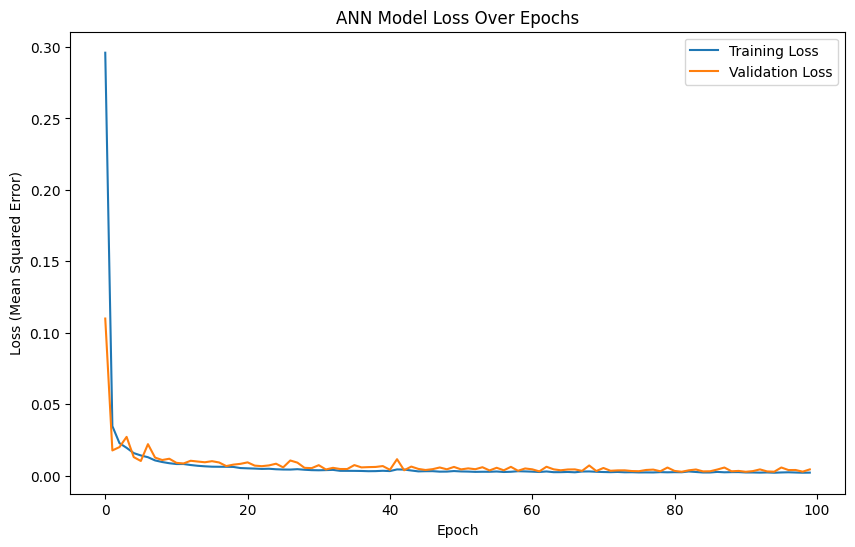

Initial last_sequence_ann shape: (1, 60)
First few values of initial last_sequence_ann:
[0.53866667 0.55155556 0.55244444 0.56044444 0.60088889]
Predicted future 'Close/Last' prices using ANN:
        Date  Predicted Close/Last (ANN)
0 2026-02-15                   26.338568
1 2026-02-22                   26.838787
2 2026-03-01                   27.064018
3 2026-03-08                   27.981565
4 2026-03-15                   27.897358
5 2026-03-22                   27.644310
6 2026-03-29                   28.303593
7 2026-04-05                   28.079931


In [ ]:
# 1. Reuse the `scaled_data` and the `look_back` period that were previously defined.
# scaled_data and look_back are already available from previous steps

# 2. Apply the `create_sequences` function to `scaled_data` and `look_back` to generate
# input sequences (`X_ann`) and target values (`y_ann`) for the ANN model.
# The create_sequences function was defined in a previous step.
# Defining it again to ensure it's available in this cell context if notebook is run out of order.
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

X_ann, y_ann = create_sequences(scaled_data, look_back)

# 3. Reshape the input sequences `X_ann` from the 3D format `(samples, timesteps, features)`
# to a 2D format `(samples, timesteps)` as required for a typical feedforward ANN.
# The `features` dimension should be removed since we are only using a single feature ('Close/Last').
X_ann = X_ann.reshape(X_ann.shape[0], X_ann.shape[1])

# 4. Print the shapes of `X_ann` and `y_ann` to verify the new dimensions.
print(f"Shape of X_ann (input sequences for ANN): {X_ann.shape}")
print(f"Shape of y_ann (target values for ANN): {y_ann.shape}")

#from keras.models import Sequential
#from keras.layers import Dense, Input

# 2. Initialize a Sequential model.
model_ann = Sequential()

# 3. Add an Input layer to the model, specifying its shape as (look_back,)
model_ann.add(Input(shape=(look_back,)))

# 4. Add at least two Dense layers to the model with an activation function
model_ann.add(Dense(units=100, activation='relu'))
model_ann.add(Dense(units=50, activation='relu'))

# 5. Add a final Dense output layer with one unit and no activation function (for regression).
model_ann.add(Dense(units=1))

# 6. Compile the model using the 'adam' optimizer and 'mean_squared_error' loss function.
model_ann.compile(optimizer='adam', loss='mean_squared_error')

# 7. Print the model summary using model.summary() to display its architecture.
model_ann.summary()

history_ann = model_ann.fit(
    X_ann,
    y_ann,
    epochs=100,      # Number of training iterations
    batch_size=32,   # Number of samples per gradient update
    validation_split=0.2, # Fraction of the training data to be used as validation data
    verbose=1        # Display training progress
)

print("ANN model training complete.")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
plt.plot(history_ann.history['loss'], label='Training Loss')
plt.plot(history_ann.history['val_loss'], label='Validation Loss')
plt.title('ANN Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.show()


# 1. Extract the last look_back values from the scaled_data to serve as the initial input sequence.
# Reshape to (1, look_back) for ANN input.
last_sequence_ann = scaled_data[-look_back:].reshape(1, look_back)

# 2. Initialize an empty list, future_predictions_scaled_ann, to store the scaled predictions.
future_predictions_scaled_ann = []

print(f"Initial last_sequence_ann shape: {last_sequence_ann.shape}")
print(f"First few values of initial last_sequence_ann:\n{last_sequence_ann[0,:5].flatten()}")


# 3. Iterate len(future_df) times (to predict for 8 future dates):
for _ in range(len(future_df)):
    # a. Use the trained model_ann to predict the next 'Close/Last' value from the current last_sequence_ann.
    next_prediction_scaled_ann = model_ann.predict(last_sequence_ann, verbose=0)

    # b. Append this scaled prediction to the future_predictions_scaled_ann list.
    future_predictions_scaled_ann.append(next_prediction_scaled_ann[0, 0])

    # c. Update last_sequence_ann by removing its first element and adding the new scaled prediction to its end.
    # Remember to keep it as a 2D array of (1, look_back).
    new_sequence_element_ann = next_prediction_scaled_ann.reshape(1, 1)
    last_sequence_ann = np.append(last_sequence_ann[:, 1:], new_sequence_element_ann, axis=1)

# 4. Convert the future_predictions_scaled_ann list into a NumPy array and reshape it to (-1, 1).
future_predictions_scaled_array_ann = np.array(future_predictions_scaled_ann).reshape(-1, 1)

# 5. Inverse transform the future_predictions_scaled_array_ann using the scaler object
# to obtain the actual predicted 'Close/Last' prices.
future_predictions_actual_ann = scaler.inverse_transform(future_predictions_scaled_array_ann)

# 6. Add these future_predictions_actual_ann to the existing future_df DataFrame,
# creating a new column named 'Predicted Close/Last (ANN)'.
future_df['Predicted Close/Last (ANN)'] = future_predictions_actual_ann

print("Predicted future 'Close/Last' prices using ANN:")
print(future_df[['Date', 'Predicted Close/Last (ANN)']])

In [ ]:
# Calculate percentage change for LSTM predictions
lstm_prices_series = pd.concat([pd.Series([last_known_close_last]), future_df['Predicted Close/Last (LSTM)']])
future_df['Predicted Changes in % (LSTM)'] = lstm_prices_series.pct_change().iloc[1:] * 100

# Calculate percentage change for ANN predictions
ann_prices_series = pd.concat([pd.Series([last_known_close_last]), future_df['Predicted Close/Last (ANN)']])
future_df['Predicted Changes in % (ANN)'] = ann_prices_series.pct_change().iloc[1:] * 100

# Rename columns in future_df before creating the summary
# 'Predicted Status' comes from Logistic Regression model
future_df.rename(columns={'Predicted Status': 'Predicted Status (LR)'}, inplace=True)
future_df.rename(columns={'Predicted Percentage Change (RF)': 'Predicted Changes in %'}, inplace=True)

combined_predictions_summary = future_df[['Date', 'Predicted Status (LR)', 'Predicted Status (RF)', 'Predicted Status (DT)', 'Predicted Price Change (RF)', 'Predicted Changes in %', 'Predicted Changes in % (LSTM)', 'Predicted Changes in % (ANN)']].head(4
)
combined_predictions_summary

,Date,Predicted Status (LR),Predicted Status (RF),Predicted Status (DT),Predicted Price Change (RF),Predicted Changes in %,Predicted Changes in % (LSTM),Predicted Changes in % (ANN)
0,2026-02-15,Increase,Increase,Increase,0.3517,1.376517,-0.588019,3.086371
1,2026-02-22,Increase,Increase,Increase,0.3517,1.376517,1.186998,1.899190
2,2026-03-01,Increase,Increase,Increase,0.3517,1.376517,1.066727,0.839200
3,2026-03-08,Increase,Increase,Increase,NaN,NaN,0.977832,3.390285


Kone Oyj: Machine learning algorithms suggest mixed results for stock.

UPM-Kymmene: Models almost universally predict a price increase, presenting a strong "buy" signal from this analysis.

In [ ]:
classification_models_summary = pd.DataFrame.from_dict(models_accuracy, orient='index', columns=['Accuracy'])
classification_models_summary


,Accuracy
Logistic Regression,0.561905
Decision Tree,1.000000
Random Forest,1.000000


As a refresher logistic regression, decision tree and Random Forrest accuracies are mentioned here.

In [ ]:
# Make predictions on the training data using the trained LSTM model
lstm_train_predictions_scaled = model.predict(X)

# Inverse transform the scaled predictions and actual values back to original scale
lstm_train_predictions_actual = scaler.inverse_transform(lstm_train_predictions_scaled)
lstm_actual_values_actual = scaler.inverse_transform(y.reshape(-1, 1))

# Calculate MSE for LSTM
from sklearn.metrics import mean_squared_error
lstm_mse = mean_squared_error(lstm_actual_values_actual, lstm_train_predictions_actual)
print(f"LSTM Mean Squared Error: {lstm_mse:.4f}")

# Make predictions on the training data using the trained ANN model
ann_train_predictions_scaled = model_ann.predict(X_ann, verbose=0)

# Inverse transform the scaled predictions and actual values back to original scale
ann_train_predictions_actual = scaler.inverse_transform(ann_train_predictions_scaled)
ann_actual_values_actual = scaler.inverse_transform(y_ann.reshape(-1, 1))

# Calculate MSE for ANN
ann_mse = mean_squared_error(ann_actual_values_actual, ann_train_predictions_actual)
print(f"ANN Mean Squared Error: {ann_mse:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
LSTM Mean Squared Error: 1.2152
ANN Mean Squared Error: 1.3218


LSTM and ANN Mean Squared Errors calculated here. This is a measurement for testing their accuracy and reliability

Create .csv files

In [ ]:
classification_models_summary = pd.DataFrame.from_dict(models_accuracy, orient='index', columns=['Accuracy'])

# Calculate percentage change for LSTM predictions
lstm_prices_series = pd.concat([pd.Series([last_known_close_last]), future_df['Predicted Close/Last (LSTM)']])
future_df['Predicted Changes in % (LSTM)'] = lstm_prices_series.pct_change().iloc[1:] * 100

# Calculate percentage change for ANN predictions
ann_prices_series = pd.concat([pd.Series([last_known_close_last]), future_df['Predicted Close/Last (ANN)']])
future_df['Predicted Changes in % (ANN)'] = ann_prices_series.pct_change().iloc[1:] * 100

# Calculate Predicted Close/Last (RF) from Predicted Price Change (RF)
# Predicted Price Change (RF) was calculated for a subset of future dates. For these dates,
# we assume the prediction is the change from the last known 'Close/Last'.
future_df['Predicted Close/Last (RF)'] = last_known_close_last + future_df['Predicted Price Change (RF)']

# Rename columns in future_df for combined summary
future_df.rename(columns={'Predicted Status': 'Predicted Status (LR)'}, inplace=True)
future_df.rename(columns={'Predicted Percentage Change (RF)': 'Predicted Changes in %'}, inplace=True)

combined_predictions_summary = future_df[['Date', 'Predicted Status (LR)', 'Predicted Status (RF)', 'Predicted Status (DT)', 'Predicted Price Change (RF)', 'Predicted Changes in %', 'Predicted Close/Last (LSTM)', 'Predicted Changes in % (LSTM)', 'Predicted Close/Last (ANN)', 'Predicted Changes in % (ANN)', 'Predicted Close/Last (RF)']]

# Prepare historical data with clear column names
historical_df_prepared = df[[ 'Date', 'Close/Last', 'Close/Last_12M_MA', 'Turnover_EUR_12M_MA', 'RSI']].copy()
historical_df_prepared.rename(columns={
    'Close/Last': 'Actual Close/Last',
    'Close/Last_12M_MA': 'Actual Close/Last (12-Month MA)',
    'Turnover_EUR_12M_MA': 'Actual Turnover - EUR (12-Month MA)',
    'RSI': 'Actual RSI'
}, inplace=True)

# 1. Get a list of all unique column names present in both DataFrames
all_columns = list(set(historical_df_prepared.columns).union(set(combined_predictions_summary.columns)))

# 2. Define target data types for all these unique columns
target_dtypes = {}
for col in all_columns:
    if col == 'Date':
        target_dtypes[col] = 'datetime64[ns]'
    elif 'Predicted Status' in col:
        target_dtypes[col] = object  # For 'Increase'/'Decrease' strings
    else:
        target_dtypes[col] = np.float64  # All other numeric columns

# 3. Initialize an empty DataFrame, historical_final_df, with all unique columns and their respective target data types.
# Then, populate historical_final_df by assigning the columns from historical_df_prepared, ensuring data type consistency.
historical_final_df = pd.DataFrame(columns=all_columns).astype(target_dtypes)
for col in historical_df_prepared.columns:
    historical_final_df[col] = historical_df_prepared[col].astype(target_dtypes[col])

# 4. Similarly, initialize an empty DataFrame, future_final_df, with all unique columns and their respective target data types.
# Populate future_final_df by assigning the columns from combined_predictions_summary, ensuring data type consistency.
future_final_df = pd.DataFrame(columns=all_columns).astype(target_dtypes)
for col in combined_predictions_summary.columns:
    future_final_df[col] = combined_predictions_summary[col].astype(target_dtypes[col])

# 5. Concatenate historical_final_df and future_final_df vertically into a new DataFrame named final_consolidated_df.
final_consolidated_df = pd.concat([historical_final_df, future_final_df], ignore_index=True)

# 6. Sort final_consolidated_df by the 'Date' column in ascending order and reset its index.
final_consolidated_df = final_consolidated_df.sort_values(by='Date').reset_index(drop=True)

# Define the output filename
output_filename_consolidated = f"{name.replace(' ', '_')}_stock_analysis_results_consolidated.csv"

# Save the combined DataFrame to a CSV file
final_consolidated_df.to_csv(output_filename_consolidated, index=False)

print(f"Consolidated historical and prediction data saved to {output_filename_consolidated}")
print("Head of the consolidated DataFrame:")
print(final_consolidated_df.head())
print("\nTail of the consolidated DataFrame:")
print(final_consolidated_df.tail())

**References:**

Gers, F.A., Schraudolph, N.N. and Schmidhuber, J. (2002) 'Learning Precise Timing with LSTM Recurrent Networks', Journal of Machine Learning Research, 3, pp. 115-143 (Accessed: 15 March 2026).

Lang, N. (2021) What are Artificial Neural Networks?, Data Basecamp, 25 November. Available at: https://databasecamp.de/en/ml/artificial-neural-networks (Accessed: 15 March 2026).

Tolles, J. and Meurer, W.J. (2016) 'Logistic Regression: Relating Patient Characteristics to Outcomes', JAMAevidence. Available at: https://jamaevidence.mhmedical.com/content.aspx?bookId=2742&sectionId=233567606 (Accessed: 15 March 2026).